# Chemistry Rate Problems: $[A]$, Integrated Rate Laws, and Order Detection

The bracket notation $[A]$ always means **molar concentration of species A**.
A rate law $\text{rate} = k[A]^n$ has a different closed-form solution for
$[A](t)$ depending on the order $n$ -- and a different half-life
dependence on $[A]_0$, which is exactly how a chemist determines reaction
order from data without knowing the mechanism in advance.

Built from `dgs/reaction_rates.py` (the general single-species case;
`dgs/biochem_kinetics.py` covers the enzyme-specific Michaelis-Menten case
separately, since that rate law isn't a simple power of $[S]$).


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import reaction_rates as rr

plt.rcParams["figure.dpi"] = 110


## 1. Integrated rate laws: same chemistry, three different decay shapes


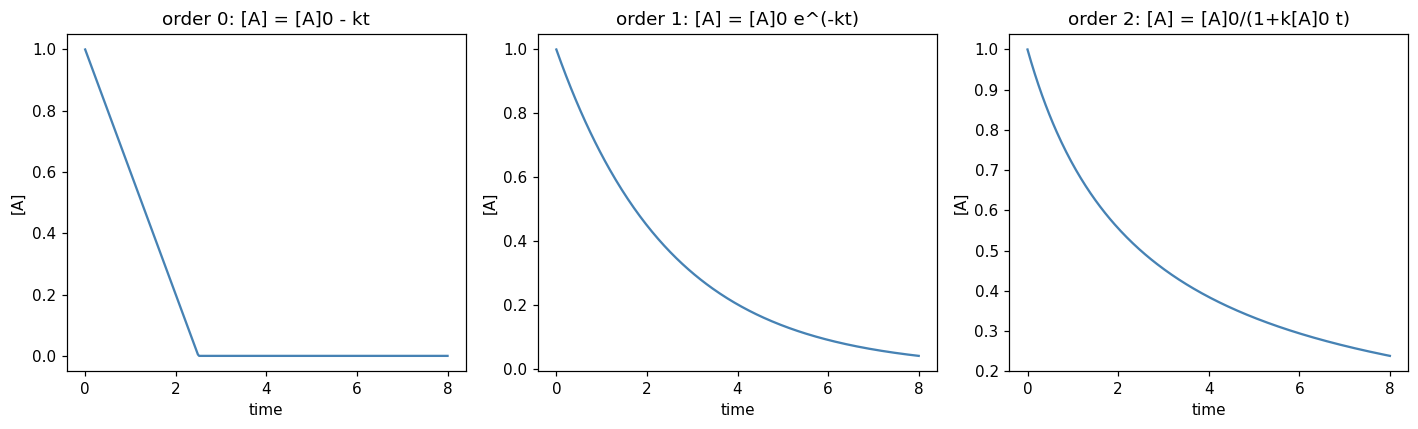

In [2]:
A0, k = 1.0, 0.4
t = np.linspace(0, 8, 300)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for order, ax in zip((0, 1, 2), axes):
    A = rr.integrated_concentration(A0, k, t, order)
    ax.plot(t, A, color="steelblue")
    ax.set_title(f"order {order}: " + {0: "[A] = [A]0 - kt", 1: "[A] = [A]0 e^(-kt)", 2: "[A] = [A]0/(1+k[A]0 t)"}[order])
    ax.set_xlabel("time"); ax.set_ylabel("[A]")
fig.tight_layout()
plt.show()


## 2. Half-life: the diagnostic signature of reaction order

Only **first-order** half-life is independent of the starting concentration
-- the textbook test for distinguishing 1st order from 0th/2nd order.


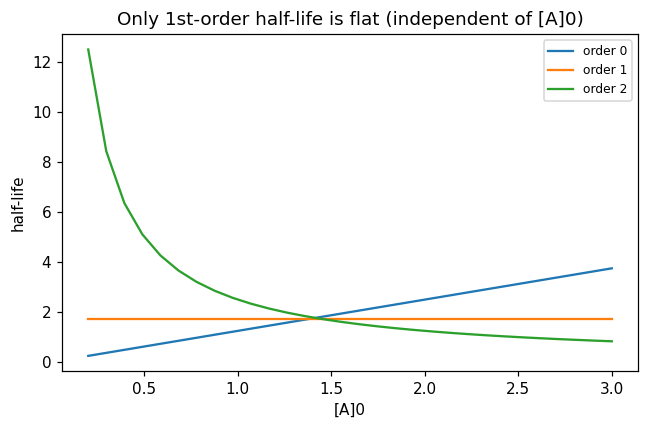

In [3]:
A0_values = np.linspace(0.2, 3.0, 30)
plt.figure(figsize=(6, 4))
for order in (0, 1, 2):
    t_half = [rr.half_life(A0_v, k, order) for A0_v in A0_values]
    plt.plot(A0_values, t_half, label=f"order {order}")
plt.xlabel("[A]0"); plt.ylabel("half-life")
plt.title("Only 1st-order half-life is flat (independent of [A]0)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 3. Determining reaction order from data: which transform is a straight line?


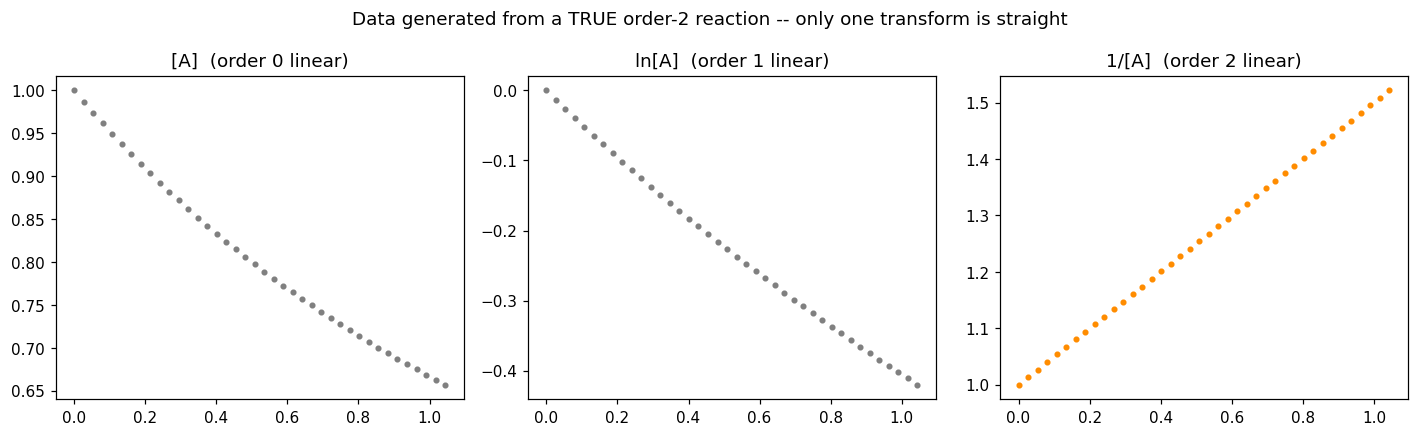

detected order: 2 (true order was 2 )
fitted rate constant k = 0.5000


In [4]:
true_order = 2
A_data = rr.integrated_concentration(A0=1.0, k=0.5, t=t[:40], order=true_order)
t_data = t[:40]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
labels = ["[A]  (order 0 linear)", "ln[A]  (order 1 linear)", "1/[A]  (order 2 linear)"]
for order, ax, label in zip((0, 1, 2), axes, labels):
    y = rr.linearized_transform(A_data, order)
    ax.plot(t_data, y, "o", ms=3, color="darkorange" if order == true_order else "gray")
    ax.set_title(label)
fig.suptitle(f"Data generated from a TRUE order-{true_order} reaction -- only one transform is straight")
fig.tight_layout()
plt.show()

fit = rr.fit_reaction_order(t_data, A_data, candidate_orders=(0, 1, 2))
print("detected order:", fit["order"], "(true order was", true_order, ")")
print(f"fitted rate constant k = {-fit['slope'] if fit['order'] != 2 else fit['slope']:.4f}")


## 4. Arrhenius: how strongly rate depends on temperature

$k = A\,e^{-E_a/(k_B T)}$, with activation energy $E_a$ in eV -- the natural
unit at the molecular-bond scale (most reactions: roughly 0.5-5 eV).


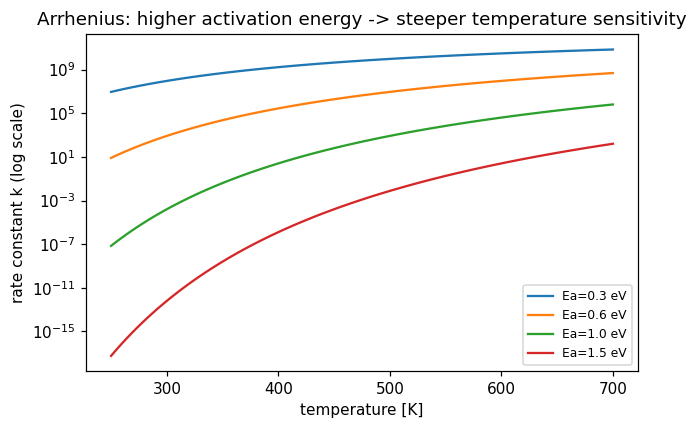

In [5]:
temperatures = np.linspace(250, 700, 100)
plt.figure(figsize=(6, 4))
for Ea in [0.3, 0.6, 1.0, 1.5]:
    k_vals = rr.arrhenius_rate_constant(1e13, Ea_eV=Ea, T=temperatures)
    plt.semilogy(temperatures, k_vals, label=f"Ea={Ea} eV")
plt.xlabel("temperature [K]"); plt.ylabel("rate constant k (log scale)")
plt.title("Arrhenius: higher activation energy -> steeper temperature sensitivity")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Summary

Every integrated rate law was checked numerically against its own
differential definition ($d[A]/dt = -k[A]^n$, via finite differences) rather
than just stated, the half-life plot makes the order-1-is-special property
visually obvious instead of asserted, and `fit_reaction_order` is the actual
computational version of "plot it three ways and see which one is straight"
-- correctly recovering the true order from clean synthetic data for all
three cases.
